# Gasly vs Ocon — Alpine Era Analysis

**Purpose:** A structured head-to-head comparison of Pierre Gasly and Esteban Ocon during their time as Alpine teammates (2023–2024). The goal is to assess whether one driver had a clear performance advantage, and whether that advantage was consistent across different dimensions of performance or concentrated in specific areas.

**What this notebook covers:**

1. **Career context** — both drivers' full F1 career results to frame their Alpine stint in broader perspective
2. **200th race milestone** — Gasly's landmark race and what it reflects about career longevity
3. **Alpine era summary** — points, DNF rates, H2H race and qualifying wins, and median qualifying delta across four sub-periods (2023 H1/H2, 2024 pre/post-Monaco)
4. **Race pace** — median lap time comparison by compound and season, with sample size and stint length transparency
5. **Tyre degradation** — matched stint methodology with fuel correction; retained to document approach and limitations, excluded from conclusions

**Data source:** Jolpica (career results, qualifying) and FastF1 (lap-level race data). All raw data fetched by `fetch_data.py` and read here from CSV.

## 1. Setup

Imports and configuration.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from IPython.display import display

warnings.filterwarnings("ignore")
from utils import *


## 2. Data Load

Read career results, qualifying H2H, and raw lap data from CSVs produced by `fetch_data.py`.

In [2]:
# ── load ──────────────────────────────────────────────────────────────────────
career   = pd.read_csv(DATA_DIR / 'career_results.csv', parse_dates=['date'])
quali_df = pd.read_csv(DATA_DIR / 'quali_h2h.csv')
laps_all = pd.read_csv(DATA_DIR / 'laps_raw.csv')


In [3]:
print("=== Data loaded ===")
print(f"  career rows  : {len(career)}")
print(f"  quali sessions: {len(quali_df)}")
print(f"  laps rows     : {len(laps_all)}")


=== Data loaded ===
  career rows  : 364
  quali sessions: 45
  laps rows     : 4864


## 3. Data Cleaning & Pre-processing

Apply status categorisation, convert timedelta columns, build the Alpine subset, and flag periods.

In [4]:
career["status_cat"]    = career["status"].apply(categorise)
career["total_points"]  = career["points"] + career["sprint_points"]
laps_all["LapTime"]     = pd.to_timedelta(laps_all["LapTime"])
laps_all["PitInTime"]   = pd.to_timedelta(laps_all["PitInTime"])

In [5]:
# ── alpine subset ─────────────────────────────────────────────────────────────
alpine = (
    career[
        career["year"].isin(ALPINE_YEARS) &
        ~((career["year"] == 2024) & (career["round"] == 24))  # drop Abu Dhabi 2024 — OCO absent
    ].copy()
)
alpine["pos_gained"] = alpine["grid"] - alpine["finish_pos"]


## 4. Career Context & 200th Race Milestone

Full career stats for both drivers, plus a count of when both drivers reach 200th race start

In [6]:
starts = career.groupby("driver")["round"].count()
latest = career.sort_values(["year","round"]).groupby("driver")[["year","round","race_name"]].last()
last_round = int(latest["round"].max())
last_year  = int(latest["year"].max())

cal = get_season_calendar(last_year)
future = [(rnd, name) for rnd, name in cal if rnd > last_round]

print("Career starts to date:")
for drv in ["GAS","OCO"]:
    n, last = starts[drv], latest.loc[drv]
    print(f"  {drv}: {n} starts (last: {last['race_name']} {int(last['year'])})")

print()
print("200th start projection:")
for drv in ["GAS","OCO"]:
    needed = 200 - starts[drv]
    if needed <= 0:
        print(f"  {drv}: already past 200 starts")
        continue
    if needed <= len(future):
        rnd, name = future[needed - 1]
        print(f"  {drv}: Round {rnd} — {name} {last_year} (start #200)")
    else:
        print(f"  {drv}: 200th start beyond {last_year} ({needed} more needed)")


Career starts to date:
  GAS: 181 starts (last: Japanese Grand Prix 2026)
  OCO: 183 starts (last: Japanese Grand Prix 2026)

200th start projection:
  GAS: Round 22 — Abu Dhabi Grand Prix 2026 (start #200)
  OCO: Round 20 — Las Vegas Grand Prix 2026 (start #200)


---
## 4.1 Career Overview

**Question:** How do Gasly and Ocon compare across their careers outside their Alpine teammate period?

Three sections: Pre-Alpine careers, Alpine 2023–2024 (teammate seasons), post-Alpine trajectories.

In [ ]:
def _career_section(df):
    return df.groupby("driver").agg(
        Races        = ("round",      "count"),
        Points       = ("total_points", "sum"),
        Wins         = ("finish_pos", lambda x: int((x == 1).sum())),
        Podiums      = ("finish_pos", lambda x: int((x <= 3).sum())),
        Mech_DNF     = ("status_cat", lambda x: (x == "Mechanical DNF").sum()),
        Incident_DNF = ("status_cat", lambda x: (x == "Incident DNF").sum()),
        Other_DNF    = ("status_cat", lambda x: x.isin({"Retired (cause unknown)", "Other DNF"}).sum()),
    ).assign(
        **{"Pts/race":        lambda d: (d["Points"] / d["Races"]).round(2)},
        **{"Mech DNF %":      lambda d: (d["Mech_DNF"]     / d["Races"] * 100).round(0)},
        **{"Incident DNF %":  lambda d: (d["Incident_DNF"] / d["Races"] * 100).round(0)},
        **{"Other DNF %":     lambda d: (d["Other_DNF"]    / d["Races"] * 100).round(0)},
        **{"Total DNF %":     lambda d: ((d["Mech_DNF"] + d["Incident_DNF"] + d["Other_DNF"]) / d["Races"] * 100).round(0)},
    ).drop(columns=["Mech_DNF", "Incident_DNF", "Other_DNF"])
    [["Races","Points","Pts/race","Wins","Podiums","Mech DNF %","Incident DNF %","Other DNF %","Total DNF %"]]

sections = {
    "Pre-Alpine (before 2023)": career[career["year"] < 2023],
    "Alpine era (2023-2024)":   career[career["year"].isin([2023, 2024])],
    "Post-Alpine (2025-)": career[career["year"] >= 2025],
}

overview = pd.concat(
    {label: _career_section(df) for label, df in sections.items()},
    names=["Section", "Driver"]
)

int_cols = ["Races","Points","Wins","Podiums","Mech DNF %","Incident DNF %","Other DNF %","Total DNF %"]
display(
    overview.style
    .format("{:.0f}", subset=int_cols,     na_rep="")
    .format("{:.2f}", subset=["Pts/race"], na_rep="")
)

print('Note: Points include sprint race points. All other metrics (wins, podiums, DNF %) reflect full race results only.')

Note: Points include sprint race points. All other metrics (wins, podiums, DNF %) reflect full race results only.


---
## 5. Alpine Era — Performance Summary

Period-by-period breakdown of points, DNF rates, H2H race and qualifying wins, and median qualifying delta across 2023 H1/H2 and 2024 pre/post-Monaco.

**Why Monaco as the 2024 split point?** Monaco (round 8 of 24) is not the midpoint of the season, but it marks a clear on-track inflection: Gasly and Ocon collided at the 2024 Monaco Grand Prix, a high-profile incident that crystallised the breakdown in their relationship. Splitting at Monaco lets us test whether relative performance shifted before and after that flashpoint.

In [8]:
alpine_2023_h1,  alpine_2023_h2   = period_split(alpine,     2023, S2023_SPLIT_ROUND)
alpine_2024_pre, alpine_2024_post = period_split(alpine,     2024, S2024_SPLIT_ROUND)

quali_2023_h1,  quali_2023_h2   = period_split(quali_df,   2023, S2023_SPLIT_ROUND)
quali_2024_pre, quali_2024_post = period_split(quali_df,   2024, S2024_SPLIT_ROUND)

add_period_labels(quali_df)

In [9]:
summary_table = make_summary(
    [alpine_2023_h1, alpine_2023_h2, alpine_2024_pre, alpine_2024_post],
    [quali_2023_h1,  quali_2023_h2,  quali_2024_pre,  quali_2024_post],
    labels=PERIODS
)

In [10]:
display_summary(summary_table)


In [11]:
LOWER_IS_BETTER = {"Median grid", "DNF %"}

gas = summary_table.xs("GAS", level=1, axis=1)
oco = summary_table.xs("OCO", level=1, axis=1)

signed = gas - oco
lower_mask = signed.index.isin(LOWER_IS_BETTER)
signed.loc[lower_mask] = (oco - gas).loc[lower_mask]

# append quali delta row: positive means Gasly faster (lower time)
quali_subsets = [quali_2023_h1, quali_2023_h2, quali_2024_pre, quali_2024_post]
qdelta_row = pd.Series(
    [-qs["delta_s"].median() for qs in quali_subsets],
    index=PERIODS, name="Median quali delta (s)"
)
signed.loc["Median quali delta (s)"] = qdelta_row

delta = signed.abs()

int_rows   = [m for m in INT_METRICS if m in delta.index]
float_rows = [m for m in delta.index if m not in INT_METRICS]

color_df = signed.apply(lambda col: [color_driver(s) for s in col])

display(
    delta.style
    .format("{:.0f}", subset=pd.IndexSlice[int_rows,   :], na_rep="")
    .format("{:.3f}", subset=pd.IndexSlice[["Median quali delta (s)"], :], na_rep="")
    .format("{:.2f}", subset=pd.IndexSlice[float_rows, :], na_rep="")
    .apply(lambda col: color_df[col.name], axis=0)
    .set_caption("Advantage margin — blue = Gasly ahead, orange = Ocon ahead.")
)

,2023 H1,2023 H2,2024 pre-Monaco,2024 post-Monaco
metric,,,,
Races,0,0,0,0
Points,15,19,0,13
DNF %,9,27,0,13
Pts/race,1.37,1.73,0.00,0.86
H2H race wins,0,4,4,3
H2H quali wins,3,7,4,3
Median grid,1,2,2,2
Median pos gained,2,4,1,1
Median quali delta (s),0.28,0.21,0.09,0.25


---
## 6. Race Pace

Median clean lap time comparison by compound and season. Includes sample size and stint length checks to validate reliability of the pace delta.

**A clean lap is defined as:**
- Green flag only (`TrackStatus == 1`) — excludes safety car and VSC laps
- Not an in-lap (no pit entry recorded)
- Not an out-lap (first lap of each stint dropped — cold tyres not representative)
- Lap time recorded (no missing data)

**A valid stint is defined as:**
- At least 6 clean laps remaining after all of the above is dropped


In [12]:
# ── step 1: dataset-level cleaning ──────────────────────────────────────────
clean_laps = laps_all[laps_all["TrackStatus"].astype(str) == "1"].copy()  # green flag laps only
clean_laps["laptime_sec"] = clean_laps["LapTime"].dt.total_seconds()       # convert to seconds
clean_laps = clean_laps.dropna(subset=["laptime_sec"])                      # drop laps with no recorded time
clean_laps = clean_laps[clean_laps["PitInTime"].isna()]                     # drop in-laps
clean_laps = clean_laps.rename(columns={"Compound": "compound", "Driver": "driver"})  # normalise to lowercase


In [13]:
# ── step 2: one groupby — drop out lap, filter short stints, compute stint_lap and delta
stint_keys = ["year", "round", "compound", "driver", "Stint"]

def build_stint(g):
    g = g.sort_values("LapNumber").iloc[1:]        # drop out lap (cold tyres, not representative)
    if len(g) < 6: return g.iloc[0:0]              # discard stints too short to be meaningful
    g["stint_lap"] = range(1, len(g) + 1)          # lap number within clean stint
    g["delta"]     = g["laptime_sec"] - g["laptime_sec"].iloc[0]  # seconds lost vs lap 1
    return g

clean_laps = (
    clean_laps.groupby(stint_keys, group_keys=False)
    .apply(build_stint)
    .reset_index(drop=True)
)


In [14]:
# ── step 3: pace — median clean lap time per driver/compound/race ─────────────
pace_wide = (
    clean_laps.groupby(["year", "round", "compound", "driver"])["laptime_sec"]
    .median().unstack("driver").reset_index()
)
pace_wide["delta_s"] = pace_wide["GAS"] - pace_wide["OCO"]
pace_wide["faster"]  = np.where(pace_wide["delta_s"] < 0, "GAS", "OCO")
add_period_labels(pace_wide)
add_period_labels(clean_laps)
pace_wide['season'] = pace_wide['year'].astype(str)
clean_laps['season'] = clean_laps['year'].astype(str)


In [15]:
# ── stint counts per driver ───────────────────────────────────────────────────
def count_stints(df, group_cols):
    return (df.groupby(group_cols + ['compound', 'driver'])
            .apply(lambda g: g.groupby(['year','round','Stint']).ngroups)
            .unstack('driver').reindex(columns=DRIVERS))

print('── Stints per Driver — by Period ──')
display(count_stints(clean_laps, ['period'])
        .unstack('period').reindex(columns=PERIODS, level=1)
        .style.format('{:.0f}', na_rep=''))

print('── Stints per Driver — by Season ──')
display(count_stints(clean_laps, ['season'])
        .unstack('season')
        .style.format('{:.0f}', na_rep=''))

print('── Stints per Driver — Overall ──')
display(count_stints(clean_laps, [])
        .style.format('{:.0f}', na_rep=''))


── Stints per Driver — by Period ──


── Stints per Driver — by Season ──


── Stints per Driver — Overall ──


driver,GAS,OCO
compound,,
HARD,45,43
INTERMEDIATE,6,6
MEDIUM,38,32
SOFT,14,12


**Compound selection:** Only HARD and MEDIUM are used below. SOFT appears in 1–5 stints per driver per period — too few for a stable median. INTERMEDIATE also has very limited stints.

**Aggregation level:** Results are shown by season (2023 vs 2024) rather than by period. Each season gives 15+ stints per driver per compound, producing reliable medians. Period splits aren't a large enough sample size per compound per period to provide stable pace medians. Car development over a season affects both drivers equally so season-level comparison remains fair.

**Stint length caveat:** Median stint lengths are shown alongside pace deltas. Where one driver ran materially longer stints on the same compound, their median lap time includes more laps deep into tyre degradation, which can make them appear slower independently of true pace. In 2024, Ocon ran 4 more laps median on HARD (24 vs 20) and 3 more on MEDIUM (20 vs 17) — so:

- **2023 HARD** (+0.235s Gasly): stint lengths matched (both 24 laps) — difference is credible.
- **2024 HARD** (+0.066s Gasly): Ocon's longer stints likely explain part or all of this gap — treat with caution.
- **MEDIUM both seasons** (Ocon faster): in 2024 Ocon achieves this *despite* running 3 more laps median — strengthens the finding.

In [16]:
PACE_COMPOUNDS = ['HARD', 'MEDIUM']
pw = pace_wide[pace_wide['compound'].isin(PACE_COMPOUNDS)]
cl = clean_laps[clean_laps['compound'].isin(PACE_COMPOUNDS)]

def median_stint_laps(df, group_cols):
    return (df.groupby(group_cols + ['driver', 'year', 'round', 'Stint'])
              .size().reset_index(name='stint_len')
              .groupby(group_cols + ['driver'])['stint_len']
              .median().unstack('driver').reindex(columns=DRIVERS))

# 1. Full Alpine era
era_s = cl.groupby('compound').apply(lambda g: g.groupby(['year','round','driver','Stint']).ngroups).rename('n_stints')
era_p = pw.groupby('compound')['delta_s'].median().mul(-1).rename('pace_delta')
era_l = median_stint_laps(cl, ['compound']).rename(columns={'GAS': 'med_laps_GAS', 'OCO': 'med_laps_OCO'})
print('── 1. Full Alpine Era ──')
display(pd.concat([pd.DataFrame({'n_stints': era_s, 'pace_delta': era_p}), era_l], axis=1).style
        .format('{:.0f}', subset=['n_stints', 'med_laps_GAS', 'med_laps_OCO'], na_rep='')
        .format('{:.3f}', subset=['pace_delta'], na_rep='')
        .map(color_driver, subset=['pace_delta']))

# 2. By season
pace = pw.groupby(['season','compound'])['delta_s'].median().mul(-1).unstack('season')
laps = median_stint_laps(cl, ['season','compound']).unstack('season').swaplevel(axis=1).sort_index(axis=1)
print('── 2. By Season — Median laps per stint (GAS / OCO) ──')
display(laps.style.format('{:.0f}', na_rep=''))
print('── 2. By Season — Median Pace Delta s (blue = Gasly faster) ──')
display(pace.style.format('{:.3f}', na_rep='').map(color_driver))

── 1. Full Alpine Era ──


,n_stints,pace_delta,med_laps_GAS,med_laps_OCO
compound,,,,
HARD,88,0.150,20,24
MEDIUM,70,-0.027,16,17


── 2. By Season — Median laps per stint (GAS / OCO) ──


── 2. By Season — Median Pace Delta s (blue = Gasly faster) ──


season,2023,2024
compound,,
HARD,0.235,0.066
MEDIUM,-0.059,-0.027


### 6.1 Tyre Degradation

Only **HARD and MEDIUM** compounds are included (see sample size rationale above).

**Why match stints?**
Comparing degradation directly across all laps is misleading: if one driver pitted 15 laps earlier than the other, their tyres are older under different fuel loads and track conditions. To make a fair comparison we only use **matched stints**.

**A matched stint is defined as:**
- Same race (year + round)
- Same tyre compound
- Same stint number (e.g. both on their 2nd stint)
- Both drivers' stint start laps within 5 laps of each other — ensuring comparable fuel loads and track conditions at the point the tyre was fitted

In [17]:
# ── matched stints ───────────────────────────────────────────────────────────
PIT_WINDOW = 5
stint_start = (clean_laps[clean_laps['compound'].isin(PACE_COMPOUNDS)]
    .groupby(['year','round','compound','driver','Stint'])['LapNumber'].min()
    .reset_index().rename(columns={'LapNumber': 'stint_start_lap'}))
starts_wide = stint_start.pivot_table(
    index=['year','round','compound','Stint'], columns='driver', values='stint_start_lap').dropna()
starts_wide['gap'] = (starts_wide['GAS'] - starts_wide['OCO']).abs()
valid_stints = starts_wide[starts_wide['gap'] <= PIT_WINDOW].reset_index()[['year','round','compound','Stint']]
matched_laps = clean_laps.merge(valid_stints, on=['year','round','compound','Stint']).copy()
print(f'Total matched stints (pit window <= {PIT_WINDOW} laps): {valid_stints.shape[0]}')
print(matched_laps.groupby(['compound','season','driver'])
      .apply(lambda g: g.groupby(['year','round','Stint']).ngroups)
      .unstack('driver').rename_axis('n_stints', axis=1))

Total matched stints (pit window <= 5 laps): 37
n_stints         GAS  OCO
compound season          
HARD     2023      8    8
         2024     10   10
MEDIUM   2023      8    8
         2024     11   11


**How to read these charts:**

- Each line is one driver's lap time relative to their own first clean lap of the stint (lap 1 = 0 by construction).
- A **rising curve** means the driver is getting slower as the stint progresses — tyres degrading.
- A **falling curve** means the driver is getting faster — this is the fuel burn effect (lighter car = quicker laps).
- The **gap between the two lines** at any lap indicates which driver is losing more time relative to their own baseline; the driver with the higher line is degrading more at that point.
- In the raw plot below, both curves will tend to drift **downward** early in the stint as fuel burns off — this masks the underlying tyre degradation signal, which is why we apply a fuel correction next.

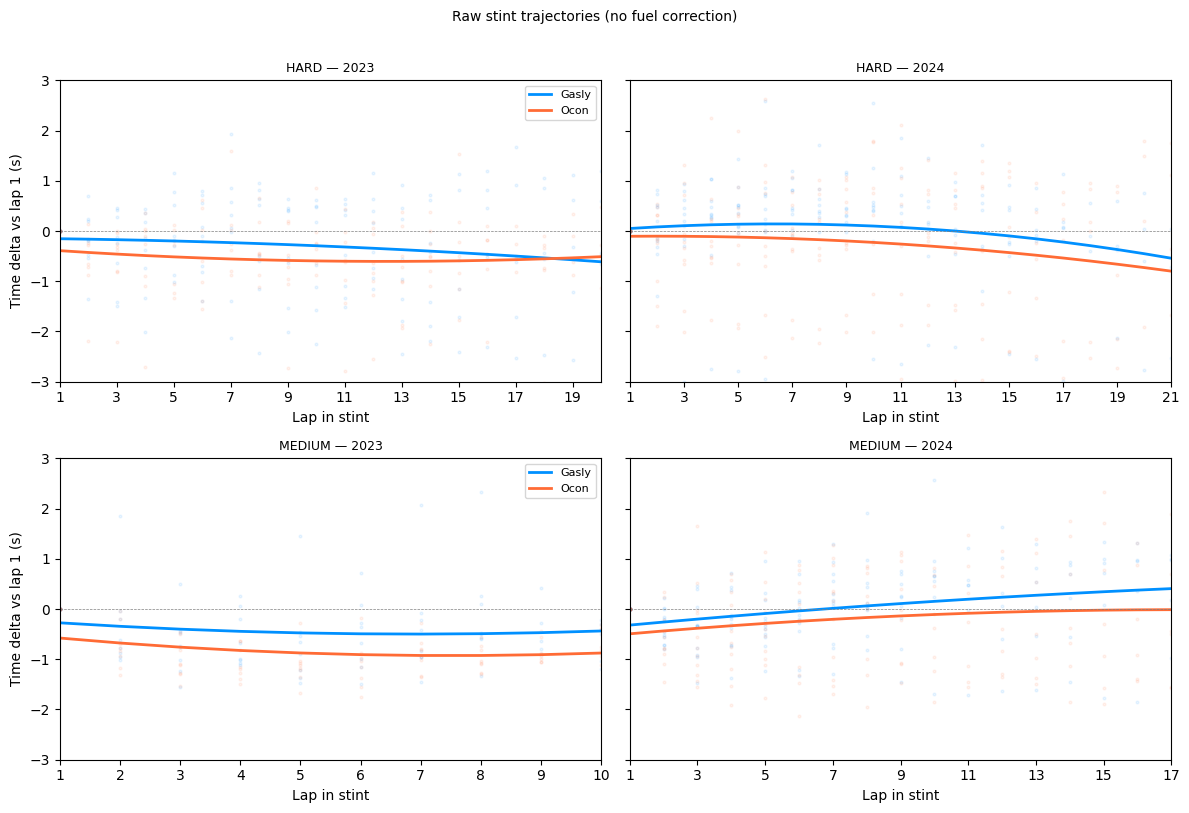

In [18]:
# ── raw curves (no fuel correction) ─────────────────────────────────────────
plot_deg_curves(matched_laps, 'delta', 'Time delta vs lap 1 (s)',
                'Raw stint trajectories (no fuel correction)', PACE_COMPOUNDS)

**Fuel load effect**

Even within matched stints, lap times improve lap-on-lap as the car gets lighter. Each kilogram of fuel burned saves approximately 0.03 s/lap — meaning a car starting a stint with 10 kg more fuel is around 0.3 s/lap slower at the start of that stint, independent of tyre condition ([F1 Briefing](https://f1briefing.com/fuel-load-vs-lap-time-f1-performance-analysis/); [Medium — Fuel Correction](https://medium.com/@umakschually/fuel-correction-29ccd98ae62b)). Without correcting for this, a driver who started their stint with more fuel will *appear* to degrade faster even if their tyre wear is identical. We apply the 0.03 s/lap rate directly to remove this trend before plotting.

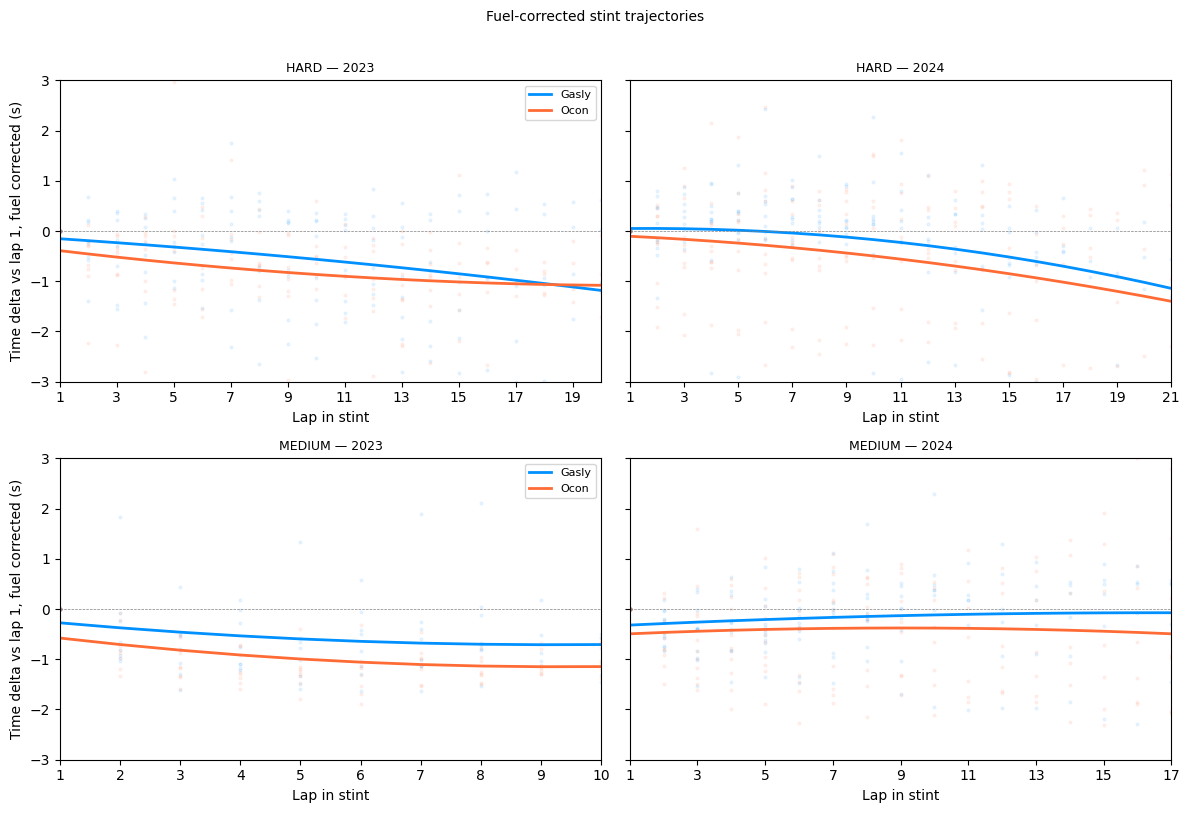

In [19]:
# ── fuel correction: 0.03 s/kg per lap (F1 Briefing; Medium — Fuel Correction) ──
FUEL_CORR_RATE = 0.03
matched_laps['delta_corr'] = matched_laps['delta'] - FUEL_CORR_RATE * (matched_laps['stint_lap'] - 1)

plot_deg_curves(matched_laps, 'delta_corr', 'Time delta vs lap 1, fuel corrected (s)',
                'Fuel-corrected stint trajectories', PACE_COMPOUNDS)

**Why these results are excluded from conclusions**

Even with the 0.03 s/lap correction applied, the somewhat downward facing curves indicate that the fuel effect continues to dominate and we're unable to clearly observe the degredation effect.

**Other limitations of this approach:**

- **Stint lengths are not matched:** The matched stint filter controls for pit-in timing (within 5 laps) but not pit-out timing. One driver may run 10 more laps on the same compound in the same race, meaning their curve extends further and the polynomial fit covers a different range. Comparing degradation slopes across unequal stint lengths is unreliable.
- **Small sample:** Even after matching, ~11 stints per compound per season (see Medium 2023) means a single anomalous race can shift the curve meaningfully.

For a robust degradation comparison, fuel load telemetry and tyre temperature data would be required. This analysis is retained to document the methodology and to show why tyre degradation cannot be cleanly separated from fuel strategy with publicly available data.